profit: 170.371 waste: 5.7% fillrate: 91.9%


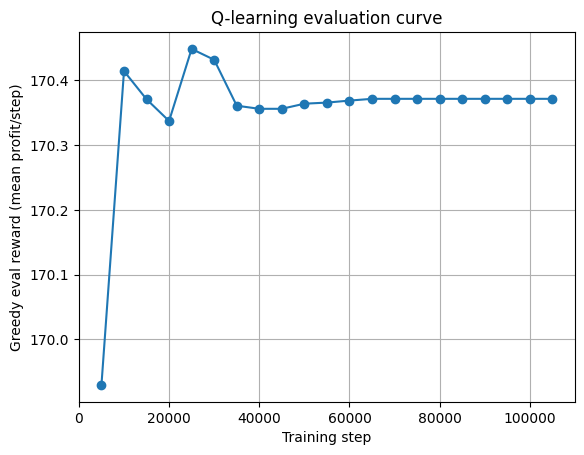

alpha=0.5, gamma=0.8, seed=1
alpha=0.5, gamma=0.8, seed=2
alpha=0.5, gamma=0.8, seed=3
alpha=0.5, gamma=0.95, seed=1
alpha=0.5, gamma=0.95, seed=2
alpha=0.5, gamma=0.95, seed=3
alpha=0.5, gamma=0.99, seed=1
alpha=0.5, gamma=0.99, seed=2
alpha=0.5, gamma=0.99, seed=3
alpha=0.3, gamma=0.8, seed=1
alpha=0.3, gamma=0.8, seed=2
alpha=0.3, gamma=0.8, seed=3
alpha=0.3, gamma=0.95, seed=1
alpha=0.3, gamma=0.95, seed=2
alpha=0.3, gamma=0.95, seed=3
alpha=0.3, gamma=0.99, seed=1
alpha=0.3, gamma=0.99, seed=2
alpha=0.3, gamma=0.99, seed=3
alpha=0.1, gamma=0.8, seed=1
alpha=0.1, gamma=0.8, seed=2
alpha=0.1, gamma=0.8, seed=3
alpha=0.1, gamma=0.95, seed=1
alpha=0.1, gamma=0.95, seed=2
alpha=0.1, gamma=0.95, seed=3
alpha=0.1, gamma=0.99, seed=1
alpha=0.1, gamma=0.99, seed=2
alpha=0.1, gamma=0.99, seed=3
Sweep complete.


In [ ]:
from scripts.environment import Environment
from scripts.Q_learning_algorithm import q_learning_with_eval
import numpy as np
import pandas as pd

alpha_list = [0.5, 0.3, 0.1]
gamma_list = [0.8, 0.95, 0.99]
seeds = [1, 2, 3]
decay = 0.9999
epsilon = 1.0
epsilon_min = 0.05
episodes = 3
eval_every = 5000

summary_rows = []
long_rows = []

for a in alpha_list:
    for g in gamma_list:
        for seed in seeds:
            print(f"alpha={a}, gamma={g}, seed={seed}")

            env = Environment(seed=seed)
            q_table, eval_steps, eval_rewards, eval_waste, eval_fill_rate = q_learning_with_eval(
                epsilon=epsilon, gamma=g, alpha=a, decay=decay, epsilon_min=epsilon_min,
                episodes=episodes, enviroment=env, eval_every=eval_every, eval_seed=seed + 1000
            )

            # final stats: mean of last 5 eval points
            summary_rows.append({
                'alpha': a,
                'gamma': g,
                'seed': seed,
                'profit': np.mean(eval_rewards[-5:]),
                'waste_pct': np.mean(eval_waste[-5:]) * 100,
                'fill_rate_pct': np.mean(eval_fill_rate[-5:]) * 100,
            })

            # full eval curve, long format
            for step, r, w, f in zip(eval_steps, eval_rewards, eval_waste, eval_fill_rate):
                long_rows.append({
                    'alpha': a,
                    'gamma': g,
                    'seed': seed,
                    'step': step,
                    'profit': r,
                    'waste_pct': w * 100,
                    'fill_rate_pct': f * 100,
                })

            # save incrementally in case of crash
            pd.DataFrame(summary_rows).to_csv('hyperparameter_tuning_summary_q.csv', index=False)
            pd.DataFrame(long_rows).to_csv('hyperparameter_tuning_long_q.csv', index=False)

print("Finished")

In [32]:
from math import sqrt
mu = 9
z = 0

print(2* mu + z * sqrt(2)* mu)

18.0


profit: 170.934 waste: 5.8% fillrate: 92.0%


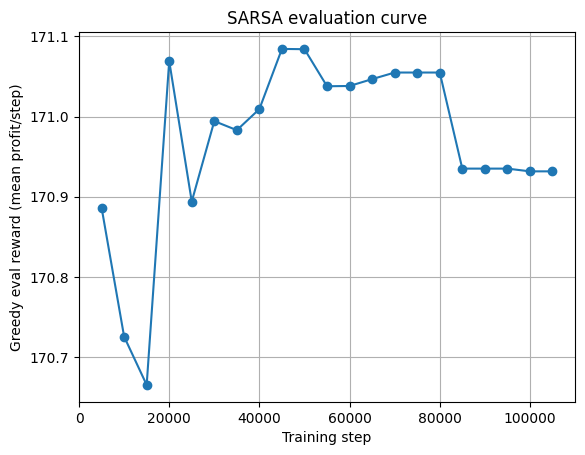

alpha=0.5, gamma=0.8, seed=1
alpha=0.5, gamma=0.8, seed=2
alpha=0.5, gamma=0.8, seed=3
alpha=0.5, gamma=0.95, seed=1
alpha=0.5, gamma=0.95, seed=2
alpha=0.5, gamma=0.95, seed=3
alpha=0.5, gamma=0.99, seed=1
alpha=0.5, gamma=0.99, seed=2
alpha=0.5, gamma=0.99, seed=3
alpha=0.3, gamma=0.8, seed=1
alpha=0.3, gamma=0.8, seed=2
alpha=0.3, gamma=0.8, seed=3
alpha=0.3, gamma=0.95, seed=1
alpha=0.3, gamma=0.95, seed=2
alpha=0.3, gamma=0.95, seed=3
alpha=0.3, gamma=0.99, seed=1
alpha=0.3, gamma=0.99, seed=2
alpha=0.3, gamma=0.99, seed=3
alpha=0.1, gamma=0.8, seed=1
alpha=0.1, gamma=0.8, seed=2
alpha=0.1, gamma=0.8, seed=3
alpha=0.1, gamma=0.95, seed=1
alpha=0.1, gamma=0.95, seed=2
alpha=0.1, gamma=0.95, seed=3
alpha=0.1, gamma=0.99, seed=1
alpha=0.1, gamma=0.99, seed=2
alpha=0.1, gamma=0.99, seed=3
Finished


In [ ]:
from scripts.environment import Environment
from scripts.sarsa_algorithm import sarsa_with_eval
import numpy as np
import pandas as pd

alpha_list = [0.5, 0.3, 0.1]
gamma_list = [0.8, 0.95, 0.99]
seeds = [1, 2, 3]
decay = 0.9999
epsilon = 1.0
epsilon_min = 0.05
episodes = 3
eval_every = 5000

summary_rows = []
long_rows = []

for a in alpha_list:
    for g in gamma_list:
        for seed in seeds:
            print(f"alpha={a}, gamma={g}, seed={seed}")

            env = Environment(seed=seed)
            q_table, eval_steps, eval_rewards, eval_waste, eval_fill_rate = sarsa_with_eval(
                epsilon=epsilon, gamma=g, alpha=a, decay=decay, epsilon_min=epsilon_min,
                episodes=episodes, enviroment=env, eval_every=eval_every, eval_seed=seed + 1000
            )

            # final stats: mean of last 5 eval points
            summary_rows.append({
                'alpha': a,
                'gamma': g,
                'seed': seed,
                'profit': np.mean(eval_rewards[-5:]),
                'waste_pct': np.mean(eval_waste[-5:]) * 100,
                'fill_rate_pct': np.mean(eval_fill_rate[-5:]) * 100,
            })

            # full eval curve, long format
            for step, r, w, f in zip(eval_steps, eval_rewards, eval_waste, eval_fill_rate):
                long_rows.append({
                    'alpha': a,
                    'gamma': g,
                    'seed': seed,
                    'step': step,
                    'profit': r,
                    'waste_pct': w * 100,
                    'fill_rate_pct': f * 100,
                })

            # save incrementally in case of crash
            pd.DataFrame(summary_rows).to_csv('hyperparameter_tuning_summary_sarsa.csv', index=False)
            pd.DataFrame(long_rows).to_csv('hyperparameter_tuning_long_sarsa.csv', index=False)

print("Finished")

Q-learning best config: alpha=0.1, gamma=0.95
SARSA best config:      alpha=0.1, gamma=0.8


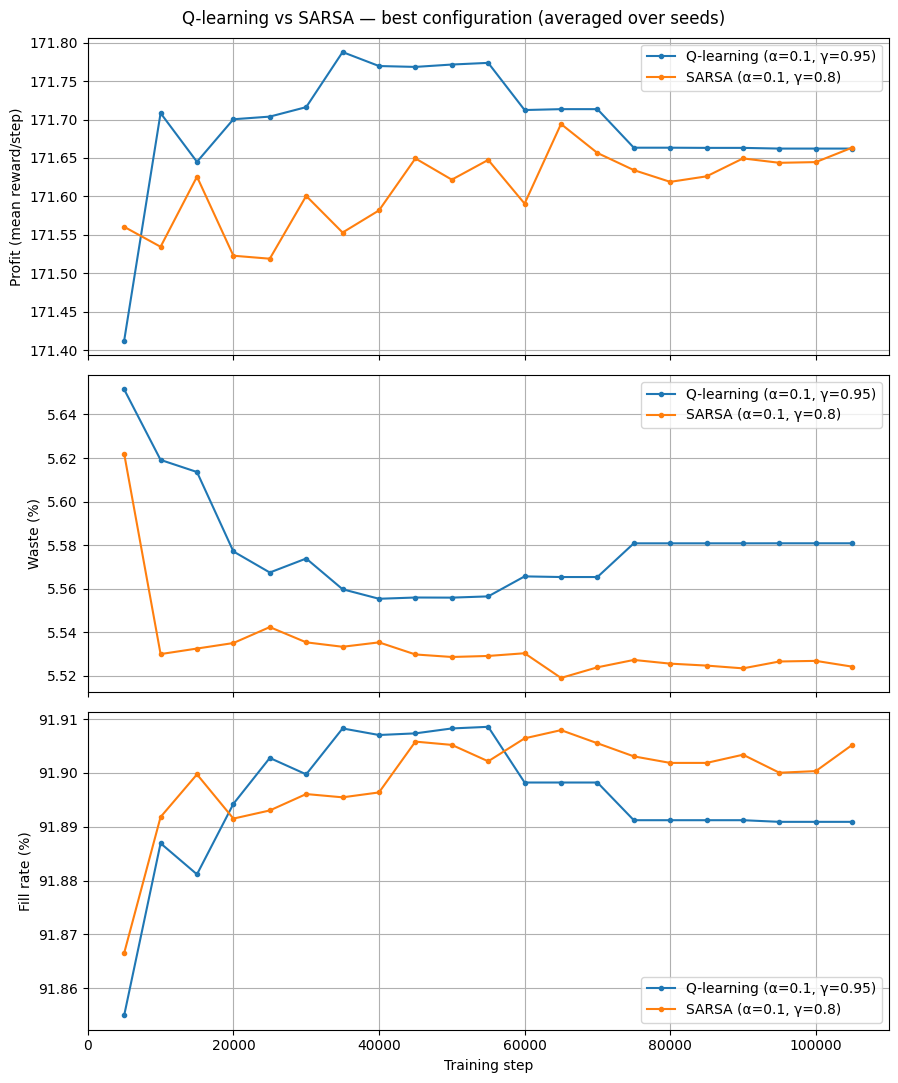

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # === load long-format eval curves ===
# ql_long = pd.read_csv('hyperparameter_tuning_long_q.csv')
# sarsa_long = pd.read_csv('sarsa_hyperparameter_tuning_long.csv')

# # === load summaries to identify best (alpha, gamma) per method ===
# ql_summary = pd.read_csv('hyperparameter_tuning_summary_q.csv')
# sarsa_summary = pd.read_csv('sarsa_hyperparameter_tuning_summary.csv')

# # average over seeds per (alpha, gamma), then pick the combo with highest mean profit
# ql_best_cfg = (ql_summary.groupby(['alpha', 'gamma'])['profit']
#                .mean().idxmax())
# sarsa_best_cfg = (sarsa_summary.groupby(['alpha', 'gamma'])['profit']
#                   .mean().idxmax())

# ql_alpha, ql_gamma = ql_best_cfg
# sarsa_alpha, sarsa_gamma = sarsa_best_cfg

# print(f"Q-learning best config: alpha={ql_alpha}, gamma={ql_gamma}")
# print(f"SARSA best config:      alpha={sarsa_alpha}, gamma={sarsa_gamma}")

# # filter long-format data to just the best config, then average curves across seeds
# ql_best = ql_long[(ql_long['alpha'] == ql_alpha) & (ql_long['gamma'] == ql_gamma)]
# sarsa_best = sarsa_long[(sarsa_long['alpha'] == sarsa_alpha) & (sarsa_long['gamma'] == sarsa_gamma)]

# ql_avg = ql_best.groupby('step')[['profit', 'waste_pct', 'fill_rate_pct']].mean().reset_index()
# sarsa_avg = sarsa_best.groupby('step')[['profit', 'waste_pct', 'fill_rate_pct']].mean().reset_index()

# # === plot ===
# fig, axes = plt.subplots(3, 1, figsize=(9, 11), sharex=True)

# metrics = [
#     ('profit', 'Profit (mean reward/step)'),
#     ('waste_pct', 'Waste (%)'),
#     ('fill_rate_pct', 'Fill rate (%)'),
# ]

# for ax, (col, label) in zip(axes, metrics):
#     ax.plot(ql_avg['step'], ql_avg[col], marker='o', markersize=3, label=f'Q-learning (α={ql_alpha}, γ={ql_gamma})')
#     ax.plot(sarsa_avg['step'], sarsa_avg[col], marker='o', markersize=3, label=f'SARSA (α={sarsa_alpha}, γ={sarsa_gamma})')
#     ax.set_ylabel(label)
#     ax.grid(True)
#     ax.legend()

# axes[-1].set_xlabel('Training step')
# fig.suptitle('Q-learning vs SARSA — best configuration (averaged over seeds)')
# plt.tight_layout()
# plt.savefig('ql_vs_sarsa_comparison.png', dpi=150)
# plt.show()